# Graded Challenge 5

Nama  : Putri Joeliya

Batch : CODA-RMT-020

Program ini dibuat untuk melakukan analisa data terhadap data yang telah di sajikan.





## Business Understanding 

### Latar Belakang Bisnis 
>Saat ini, tren kuliner seblak sedang viral dia media sosial. Melihat peluang ini, saya ingin menambah pendapatan dengan membuka toko online di Tokopedia. Namun, karena keterbatasan modal yang hanya cukup untuk biaya promosi, saya memutuskan menggunakan cara *dropship*. Sebagai lulusan Data Analytics Hacktiv8, saya ingin memastikan apakah daya tarik masyarakat benar-benar tinggi dan bagaimana karakteristik pasar seblak di Tokopedia agar strategi promosi dan penentuan harga saya tepat sasaran.

### SMART Framework 
* Specific : Menentukan kelayakan peluncuran toko dropship seblak di Tokopedia dengan menganalisis metrik harga optimal, preferensi lokasi, dan volume penjualan pasar.
* Measurable: Mencapai target volume penjualan minimal sebesar rata-rata batas bawah *Confidence Interval* pendapatan pasar dan memastikan produk yang dipilih memiliki korelasi positif terhadap minat beli.
* Achievable: Analisis ini sangat mungkin dicapai karena memanfaatkan data historis performa kompetitor seblak di Tokopedia yang sudah bersih dan siap olah.
* Relevant: Relevan dengan keterbatasan modal awal, di mana efisiensi promosi bergantung pada pemahaman harga pasar dan segmentasi wilayah yang tepat.
* Time Bound: Validasi pasar dan penentuan strategi pricing diselesaikan dalam waktu 1 minggu sebelum toko resmi dibuka.

#### Problem Steatment 
"Memvalidasi potensi pasar seblak di Tokopedia untuk menentukan strategi penetapan harga (*pricing*) dan segmentasi wilayah dropship agar mampu menghasilkan estimasi pendapatan bulanan minimum tertentu dalam waktu 1 minggu ke depan."

In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import numpy as np

df = pd.read_csv('P0G3_Putri-Joeliya_clean.csv')

df

,nama produk,harga,toko,lokasi,banyaknya terjual,rating
0,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,52000,Rasa Juara Indonesia,Kab. Bandung,50,5.0
1,Buku Komik Next G vol. 664: Tragedi Seblak | M...,34320,Mizanstore.id,Depok,50,4.9
2,Paket 2 Seblak Rangu + 2 Pangsit Rangu Nyai Me...,95060,NYAI MERCON,Kab. Garut,1000,4.9
3,"SERBA RANGU NYAI MERCON (DACI, CIPAK, PANGSIT ...",90160,NYAI MERCON,Kab. Garut,10000,4.9
4,PAKET BUNDLING TERCIKRUH (SEBLAK RANGU + CIPAK...,42630,NYAI MERCON,Kab. Garut,1000,4.9
5,Nyai Mercon - Mie Pangsit Kuah Seblak Makanan ...,27685,NYAI MERCON,Kab. Garut,1000,4.8
6,[FREE Keripik Pangsit] Paket 2 Mie Pangsit Kua...,62230,NYAI MERCON,Kab. Garut,100,4.8
7,PAKET HEMAT NYAI MERCON ( PANGSIT RANGU + SEBL...,47530,NYAI MERCON,Kab. Garut,4000,4.8
8,[HARGA SPESIAL] Paket BM 1: 2 Seblak + 1 Cuank...,61000,Rasa Juara Indonesia,Kab. Bandung,70,4.8
9,"Paket Semua Rasa Pangsit (Pangsit Rangu, Pangs...",135232,NYAI MERCON,Kab. Garut,10000,4.7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nama produk        60 non-null     object 
 1   harga              60 non-null     int64  
 2   toko               60 non-null     object 
 3   lokasi             60 non-null     object 
 4   banyaknya terjual  60 non-null     int64  
 5   rating             60 non-null     float64
dtypes: float64(1), int64(2), object(3)
memory usage: 2.9+ KB


## Dercriptive

In [21]:
metrics = ['harga', 'banyaknya terjual', 'rating'] # sesuaikan nama kolom dengan dataset Anda
for col in metrics:
    print(col.upper())
    print('Daily Steps in Average:', df[col].mean())
    print('Median of Daily Steps:', df[col].median())
    print('Standard Deviation:', df[col].std())
    print(f"Skewness : {df[col].skew()}")
    print(f"Kurtosis : {df[col].kurtosis()}")
    print(" ")

HARGA
Daily Steps in Average: 54507.1
Median of Daily Steps: 41250.5
Standard Deviation: 51595.766708394985
Skewness : 2.135232972463151
Kurtosis : 6.408460874277626
 
BANYAKNYA TERJUAL
Daily Steps in Average: 2902.95
Median of Daily Steps: 250.0
Standard Deviation: 13003.830313717803
Skewness : 7.3027564875099795
Kurtosis : 55.17534212275951
 
RATING
Daily Steps in Average: 4.833333333333333
Median of Daily Steps: 4.9
Standard Deviation: 0.19801272572242057
Skewness : -2.4877019361433415
Kurtosis : 7.611016175223323
 


##### Harga 
Hasil menunjukan adanya keberagaman harga jual seblak, dimana standar deviasinya juga menunjukan nilai tinggi dengan mayoritas produk berada di kisaran harga murah dan beberap produk memasang harga cukup tinggi terlihat dari hasil skewnessnya yaitu right skewed 

##### Banyaknya Terjual 
dari hasil yang ada terlihat adanya ketimpangan yang cukup besar mengenai jumlah terjual antar toko, terlihat dari median yang angkanya sangat jauh dari rata rata menandakan bahwa beberapa toko menarik jauh angka tersebut karna toko tersebut mungkin merupakan toko terlaris 

##### Rating 
secara umum hasilnya terlihar seimbang dimana tingkat kepuasan konsumen secara umum sangat tinggi dan seragam, dengan angaka rata rata mendekati sempurna. 


## Inferential  

##### Estimasi Pendapatan berdasarkan Conficence Interval 

In [28]:
df['pendapatan'] = df['harga'] * df['banyaknya terjual']
std_income = df['pendapatan'].std()
n = len(df)
low, up = stats.norm.interval(0.95, loc=mean_income, scale=se_income)
print(f"Rata-rata Pendapatan Sampel: Rp {mean_income:,.2f}")
print(f"Lower Limit: Rp {low:,.2f}")
print(f"Upper Limit: Rp {up:,.2f}")

Rata-rata Pendapatan Sampel: Rp 99,736,693.63
Lower Limit: Rp 29,470,859.86
Upper Limit: Rp 170,002,527.41


berdasarkan hasil analisis dengan Confidence Interval di atas di dapatkan hasil bahwa rata rata pendapatan produk seblak tercatat sebesar Rp 99,736,693.63, dengantingkat keyakinan bahwa tingkat populasi secara rata rata berada di rentang batas bawah sebesar Rp 29,470,859.86 hingga batas atas Rp 170,002,527.41 perbulan

#### Harga Berdasarkan Wilayah 
JABODETABEK vs Non JABODETABEK --> Two Sample T-Test 
> H0 : Tidak ada perbedaan harga rata-rata produk seblak yang signifikan antara wilayah Jabodetabek dan Luar Jabodetabek.

> H1 : Terdapat perbedaan harga rata-rata produk seblak yang signifikan antara wilayah Jabodetabek dan Luar Jabodetabek.

In [33]:
jabodetabek = df[df['lokasi'].str.contains('Jakarta|Bogor|Depok|Tangerang|Bekasi', case=False, na=False)]['harga']
luar_jabodetabek = df[~df['lokasi'].str.contains('Jakarta|Bogor|Depok|Tangerang|Bekasi', case=False, na=False)]['harga']



In [34]:
print('Rata-rata Jabodetabek =',jabodetabek.mean())
print('Rata-rata Luar Jabodetabek =',luar_jabodetabek.mean())

Rata-rata Jabodetabek = 52184.153846153844
Rata-rata Luar Jabodetabek = 55149.617021276594


terlihat pada hasil data rata rata harga produk yang berada di dalam dan luar Jabodetabek tidak memiliki selisih yang begitu jauh. 

In [35]:
t_stat, p_val = stats.ttest_ind(jabodetabek, luar_jabodetabek)

print('T-statistic:',t_stat)
print('P-value:',p_val)

T-statistic: -0.18190108070697275
P-value: 0.8562946068532353


dari hasil P-Value pada hasil data jika di bandingkan dengan alpha yang digunakan yaitu 5% atau 0.05 maka nilai p-value (0,856) lebih tinggi daripada 0.05 ini berarti bahwa hipotesis H0 di terima dimana tidak terdapat perbedaan harga yang signifikan antara toko yang berada di JABODETABEK dan di luar JABODETABEK.

#### Preferensi Konsumen 
Uji Korelasi 

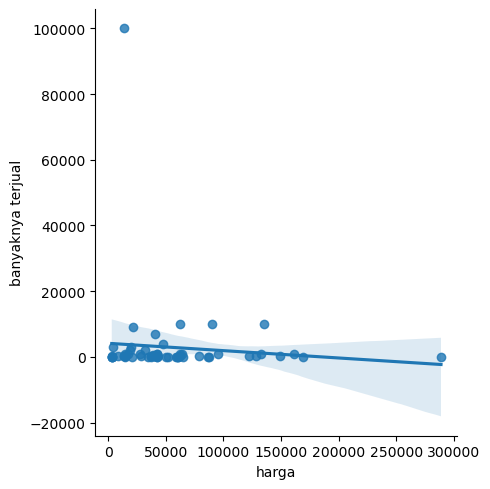

In [39]:
sns.lmplot(data=df,x='harga', y='banyaknya terjual')

produk dengan harga yang lebih murah memiliki kecenderungan terjual sedikit lebih banyak. 
selanjutnya uji Korelasi di lakukan untuk mengetahui hubungan antar 2 variabel, korelasi yang di gunakan yaotu spearman karna sebelumnya di ketahui data tidak berdistribusi normal dengan nilai skewness yang sangat jauh dari angka 0 

In [ ]:

corr_rho, pval_s = stats.spearmanr(df['harga'], df['banyaknya terjual'])
print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")

rho-correlation: 0.04, p-value: 0.7405649463793036


di karenakan p-value sebesar  0.740 merupkan nilai yang lebih besar dari pada alpha yang di gunakan yaitu 0.05 maka hubungan tersebut tidak signifikan. ini menjelaskan bahwa mahl murahnya produk tidak memiliki pengaruh terhadap banyak sedikitnya produk yang terjual di Tokopedia 

## Conclusion 
Bedarsarkan seluruh analisis yang telah dilakukan. analisa deskriptif meninjukan bahwa variabel harga dan jumlah produk terjual memiliki distribusi yang sangat condong ke kanan dengan dtandar deviasi tinggi yang mengindikasi ketimpangan pasar, sementara tingkat kepuasan konsumen tercatat tinggi dan seragam. Dari sisi finansial, estimasi Cofidence Interval 95% menunjukan bahwa rata-rata pendapatan pasar produk seblak berada di kisaran batas bawah sebesar Rp 29.470.859,86 hingga batas atas sebesar Rp 170.002.527,41 per bulan yang dapat dijadikan target omzet minimal yang realistis. Selanjutnya hasil uji hipotesis Two-Sample T-Test menunjukan tidak terdapatnya perbedaan harga rata rata yang signifikan antara wilayah jabodetabek dan luar jabodetabek. Lalu berdasarkan Uji Korelasi Spearman, di dapatkan hasil bahwa tidak ada hubungan signifikan antara harga jual dan jumlah produk yang terjual yang menjadi jawaban bahwa mahal tidaknya produk tidak di indikasikan dari mahal murahnya harga barang tersebut. 

> Secara keseluruhan, bisnis dropship seblak di Tokopedia layak untuk dijalankan dengan catatan alokasi promosi difokuskan pada strategi pemasaran yang tepat guna menarik minat target pasar.